# E1

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

En GeoPandas, read_file abre los shapefiles y cada capa conserva atributos y geometrías. Nos conviene revisar que las capas compartan el mismo CRS antes de hacer cualquier operación.

Usamos 32719 que es el sistema métrico UTM para la zona 19S, que cubre la Región Metropolitana (https://epsg.io/32719)

Esto nos permite trabajar con coordenadas en metros, lo cual es útil para cálculos de distancia y área.

In [2]:
base = 'datos_geoespaciales/'
distritos = gpd.read_file(base + 'Distritos Censales/Distritos Censales RM.shp').to_crs(32719)
estaciones = gpd.read_file(base + 'Metro 2020/Estaciones_2020/Estaciones_2020.shp').to_crs(32719)
lineas = gpd.read_file(base + 'Metro 2020/Lineas_2020/Lineas_2020.shp').to_crs(32719)
areas = gpd.read_file(base + 'Areas Urbanas/areas_urbanas.shp').to_crs(32719)
comunas = gpd.read_file(base + 'Comunas/comunas.shp').to_crs(32719)

In [3]:
areas

,NOMBRE,TIPO_AREA,SHAPE_Leng,SHAPE_Area,geometry
0,Chiguayante,Ciudad,29855.998337,1.038076e+07,"POLYGON ((140044.634 5911024.284, 140051.361 5..."
1,Lota,Ciudad,14233.349738,5.262642e+06,"POLYGON ((131359.666 5889462.902, 131475.343 5..."
2,Coronel,Ciudad,41577.791832,1.551685e+07,"POLYGON ((127278.44 5896965.436, 127411.675 58..."
3,San Rosendo,Ciudad,6499.369423,1.534402e+06,"POLYGON ((168583.83 5870293.97, 168725.579 587..."
4,Concepción,Ciudad,82986.894378,3.454227e+07,"POLYGON ((133504.854 5919782.212, 136052.58 59..."
...,...,...,...,...,...
395,Puerto Aysen,Ciudad,5410.583898,1.123116e+06,"POLYGON ((210689.999 4964388.485, 210703.516 4..."
396,Cohaique,Ciudad,17677.879995,6.317038e+06,"POLYGON ((259973.62 4947324.02, 259774.76 4947..."
397,Chile Chico,Pueblo,5641.875304,1.283623e+06,"POLYGON ((291972.658 4842628.158, 292039.346 4..."
398,Talcahuano,Ciudad,83548.165913,3.100519e+07,"POLYGON ((136052.58 5921780.429, 133504.854 59..."


In [4]:
areas[areas['NOMBRE'] == 'Santiago']

,NOMBRE,TIPO_AREA,SHAPE_Leng,SHAPE_Area,geometry
385,Santiago,Ciudad,427491.444262,5.821041e+08,"MULTIPOLYGON (((338445.291 6306151.222, 338289..."


In [5]:
santiago_urbano = areas[areas['NOMBRE'] == 'Santiago']
distritos_urbanos = gpd.overlay(santiago_urbano, distritos, how='intersection')

Usamos overlay porque queremos recortar físicamente la capa de distritos usando el polígono de santiago_urbano. Así, el resultado solo contendrá las áreas de los distritos dentro del polígono.

## Parte 1a - Nivel socioeconómico

A cada grupo le asigno un puntaje arbitrario: E=1, D=2, C3=3, C2=4 y ABC1=5. 

Para cada distrito calculo el promedio ponderado de esos puntajes, usando la cantidad de hogares de cada grupo como peso. Así, un distrito con más hogares ABC1 obtiene un puntaje mayor.

Después calculamos los puntos que separan el tercio inferior, el tercio medio y el tercio superior de los puntajes observados. Los llamo Bajo, Medio y Alto, respectivamente. 

Los pesos y los cortes son una decisión netamente modificable. Ustedes podrían hacerlo tan alambicado como quisieran, pero para efectos del ejercicio, esto es suficiente.

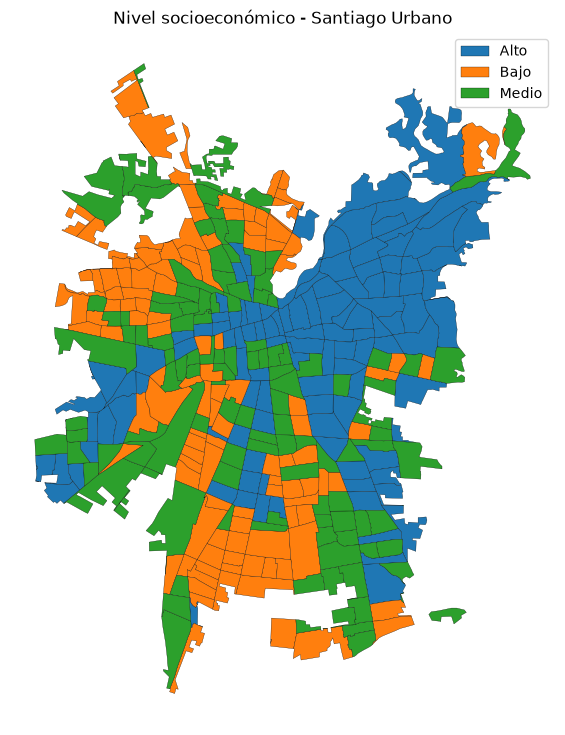

In [6]:
# puntaje asignado a cada grupo socioeconomico
puntaje_E = 1
puntaje_D = 2
puntaje_C3 = 3
puntaje_C2 = 4
puntaje_ABC1 = 5

# total de hogares considerados en cada distrito
distritos_urbanos['total_hogares'] = (
    distritos_urbanos['E'] + distritos_urbanos['D'] +
    distritos_urbanos['C3'] + distritos_urbanos['C2'] +
    distritos_urbanos['ABC1']
)

# suma ponderada -> cantidad de hogares de cada grupo por su puntaje
distritos_urbanos['suma_ponderada'] = (
    distritos_urbanos['E'] * puntaje_E +
    distritos_urbanos['D'] * puntaje_D +
    distritos_urbanos['C3'] * puntaje_C3 +
    distritos_urbanos['C2'] * puntaje_C2 +
    distritos_urbanos['ABC1'] * puntaje_ABC1
)

# promedio ponderado del distrito (queda entre 1 y 5)
distritos_urbanos['puntaje_nse'] = (
    distritos_urbanos['suma_ponderada'] / distritos_urbanos['total_hogares']
)

# Cortes que dejan aproximadamente un tercio de los distritos en cada nivel

corte_bajo = distritos_urbanos['puntaje_nse'].quantile(1/3)
corte_medio = distritos_urbanos['puntaje_nse'].quantile(2/3)

# Si el puntaje no supera el primer corte: Bajo, si no supera el segundo: Medio, los puntajes restantes se clasifican como Alto.

distritos_urbanos['nivel_nse'] = np.select(
    [
        distritos_urbanos['puntaje_nse'] <= corte_bajo,
        distritos_urbanos['puntaje_nse'] <= corte_medio
    ],
    ['Bajo', 'Medio'],
    default='Alto'
)

# mapa de los distritos coloreados según el nivel asignado

distritos_urbanos.plot(
    column='nivel_nse', categorical=True, legend=True,
    figsize=(9, 9), edgecolor='black', linewidth=0.2
)
plt.title('Nivel socioeconómico - Santiago Urbano')
plt.axis('off');

## Parte 1b - Líneas de metro en distritos de nivel alto

`overlay` permite obtener las partes de las líneas que coinciden con los polígonos de nivel alto. En el mapa se ven todas las líneas en gris y los tramos dentro de esos distritos en rojo.

Líneas que atraviesan distritos altos: ['L1', 'L2', 'L3', 'L4', 'L4A', 'L5', 'L6']


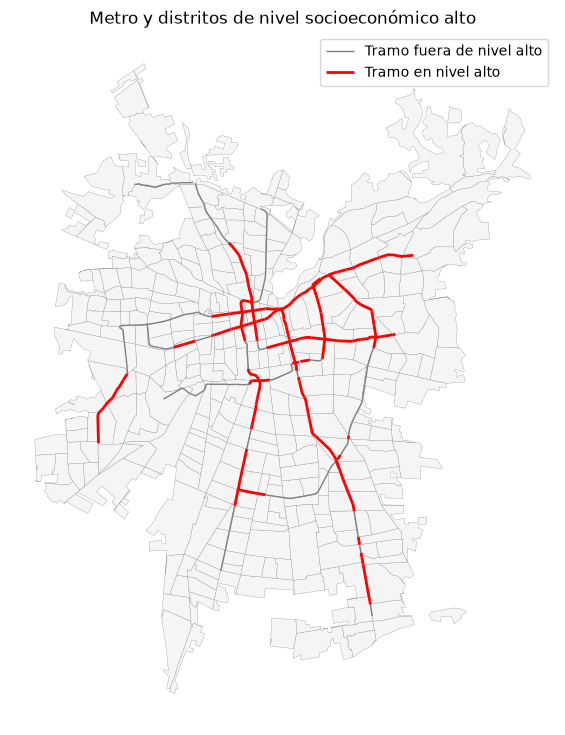

In [7]:
# cruzamos las líneas de metro con los distritos para obtener los tramos dentro de cada distrito
metro_distritos = gpd.overlay(lineas, distritos_urbanos, how='intersection')

# separo los tramos que pasan por distritos altos de los que pasan por los demás
lineas_altas = metro_distritos[metro_distritos['nivel_nse'] == 'Alto']
lineas_otras = metro_distritos[metro_distritos['nivel_nse'] != 'Alto']

ax = distritos_urbanos.plot(color='whitesmoke', edgecolor='gray', figsize=(9, 9), linewidth=0.2)
lineas_otras.plot(ax=ax, color='gray', linewidth=1, label='Tramo fuera de nivel alto')
lineas_altas.plot(ax=ax, color='red', linewidth=2, label='Tramo en nivel alto')
ax.legend()
plt.title('Metro y distritos de nivel socioeconómico alto')
plt.axis('off');
print(f"Líneas que atraviesan distritos altos: {sorted(lineas_altas['LINEA'].dropna().unique())}")

## Parte 1c - Accesibilidad al metro

Para cada centroide cuento las estaciones que quedan dentro de un buffer de 1.000 m. Como las capas están en UTM 19S, el buffer se construye en metros. 

`sjoin` relaciona cada estación con los buffers que la contienen; luego agrupo por código de distrito para obtener el conteo.

Uso cuatro rangos para resumir los conteos: 0, 1–2, 3–5 y 6 o más estaciones.

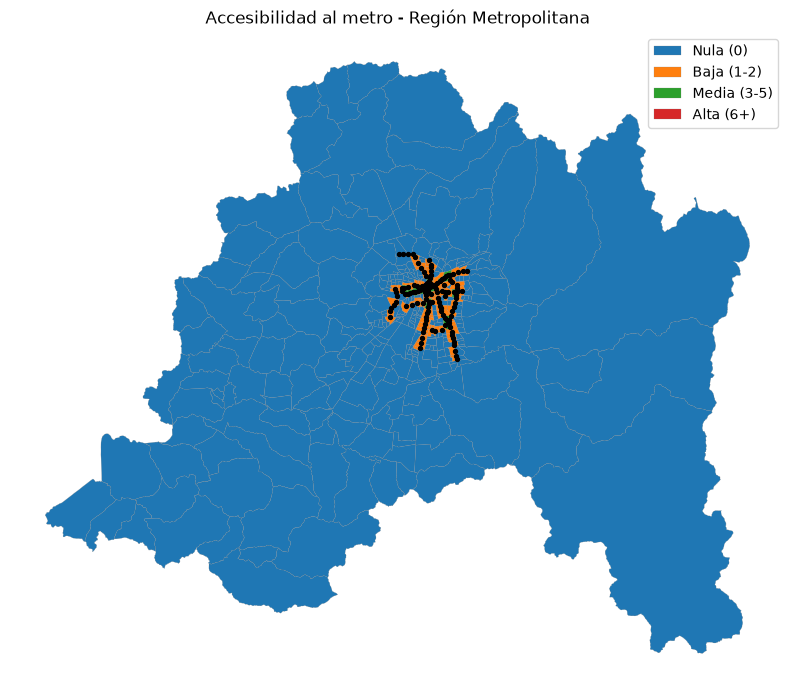

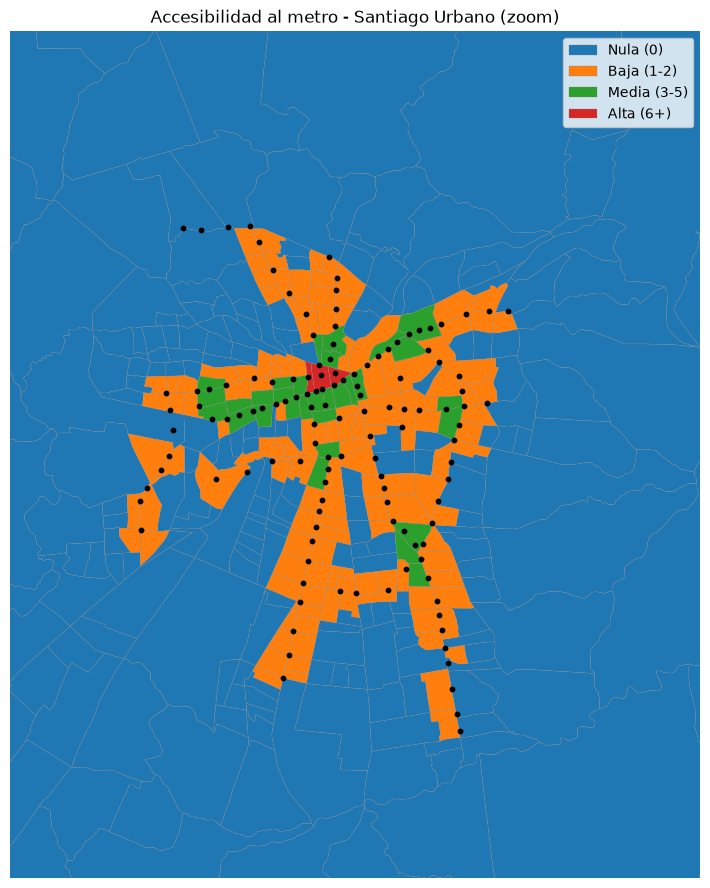

In [8]:
# Cargo los centroides distritales y me aseguro de trabajar en UTM 19S (metros)
centroides = gpd.read_file(
    base + 'Distritos Censales/centroides Distritos Censales RM.shp'
).to_crs(32719)

# Creo un buffer de 1.000 m alrededor de cada centroide
centroides['buffer_1km'] = centroides.geometry.buffer(1000)
buffers = centroides.set_geometry('buffer_1km').copy()

# Relaciono cada estación con el buffer de distrito que la contiene
estaciones_distritos = gpd.sjoin(estaciones, buffers, predicate='within')

# Cuento las estaciones por código de distrito
conteo_estaciones = estaciones_distritos.groupby('CODIGO').size()
centroides['n_estaciones'] = centroides['CODIGO'].map(conteo_estaciones).fillna(0).astype(int)

# Agrego el conteo a los polígonos distritales para poder mapearlo
distritos['n_estaciones'] = distritos['CODIGO'].map(
    centroides.set_index('CODIGO')['n_estaciones']
).fillna(0).astype(int)

# Clasifico los conteos en cuatro niveles de accesibilidad
distritos['accesibilidad'] = pd.cut(
    distritos['n_estaciones'],
    bins=[-1, 0, 2, 5, np.inf],
    labels=['Nula (0)', 'Baja (1-2)', 'Media (3-5)', 'Alta (6+)']
)

# Mapa de toda la Región Metropolitana
ax = distritos.plot(
    column='accesibilidad', categorical=True, legend=True,
    figsize=(10, 10), edgecolor='gray', linewidth=0.15
)
estaciones.plot(ax=ax, color='black', markersize=8)
plt.title('Accesibilidad al metro - Región Metropolitana')
plt.axis('off');

# Vista ampliada de Santiago Urbano
ax = distritos.plot(
    column='accesibilidad', categorical=True, legend=True,
    figsize=(11, 11), edgecolor='gray', linewidth=0.2
)
estaciones.plot(ax=ax, color='black', markersize=10)

xmin, ymin, xmax, ymax = santiago_urbano.total_bounds
ax.set_xlim(xmin - 3000, xmax + 3000)
ax.set_ylim(ymin - 3000, ymax + 3000)
plt.title('Accesibilidad al metro - Santiago Urbano (zoom)')
plt.axis('off');

## Parte 2a - Diversidad socioeconómica

La diversidad se mide con la entropía de Shannon de las proporciones E, D, C3, C2 y ABC1. Selecciono la provincia con más distritos censales y, dentro de ella, los que intersectan el área urbana.

La entropía aumenta cuando los grupos están más equilibrados; es baja cuando uno o pocos grupos concentran la mayoría. (https://metricgate.com/docs/es/entropy/)

`overlay` recorta los distritos a las geometrías urbanas, así que el mapa muestra solo la parte urbana.

Provincia con más distritos: Santiago


c:\Users\jjacq\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)


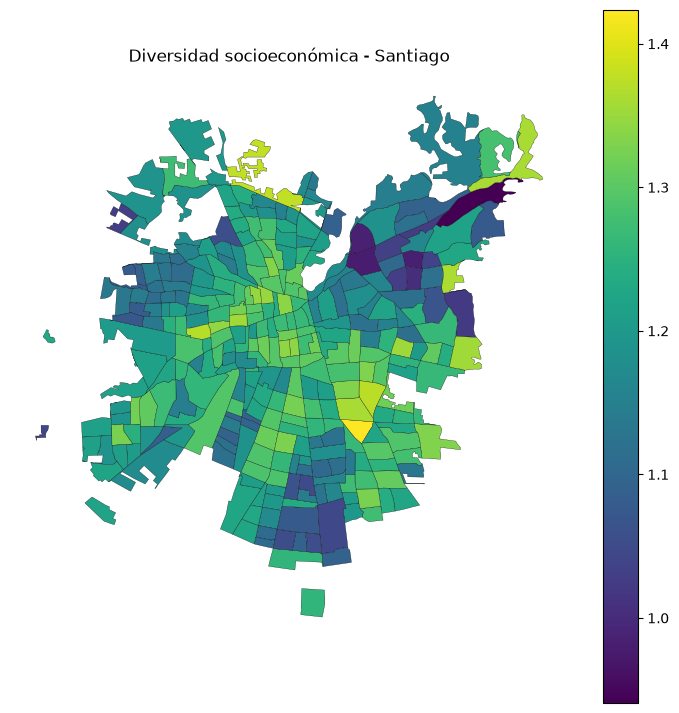

In [9]:
provincia = distritos['NOM_PROV'].value_counts().idxmax()

distritos_prov = distritos[distritos['NOM_PROV'] == provincia].copy()

urbanos_prov = gpd.overlay(distritos_prov, areas, how='intersection')

# Grupos socioeconómicos usados para calcular sus proporciones
grupos = ['E', 'D', 'C3', 'C2', 'ABC1']

proporciones = urbanos_prov[grupos].div(urbanos_prov[grupos].sum(axis=1), axis=0)

urbanos_prov['diversidad'] = -(proporciones * np.log(proporciones)).sum(axis=1)

urbanos_prov.plot(column='diversidad', cmap='viridis', legend=True,
                   figsize=(9, 9), edgecolor='black', linewidth=0.2)
plt.title('Diversidad socioeconómica - ' + provincia)
plt.axis('off');
print('Provincia con más distritos:', provincia)

## Parte 2b - Estaciones próximas a tres o más distritos

Cuento cuántos polígonos distritales intersecta un buffer de 100 m alrededor de cada estación.

El buffer representa el entorno de 100 m. 

`sjoin` relaciona ese entorno con los distritos que toca, y `nunique` cuenta códigos de distrito distintos para cada estación.

,LINEA,NOMBRE,n_distritos_100m
0,COMB,Cal y Canto,4
1,COMB,Franklin,3
2,COMB,La Cisterna,4
3,COMB,Los Heroes,4
4,COMB,Plaza Egaña,4
5,COMB,San Pablo,4
6,COMB,Santa Ana,3
7,COMB,Tobalaba,3
8,COMB,Universidad de Chile,3
9,COMB,Ñuñoa,4


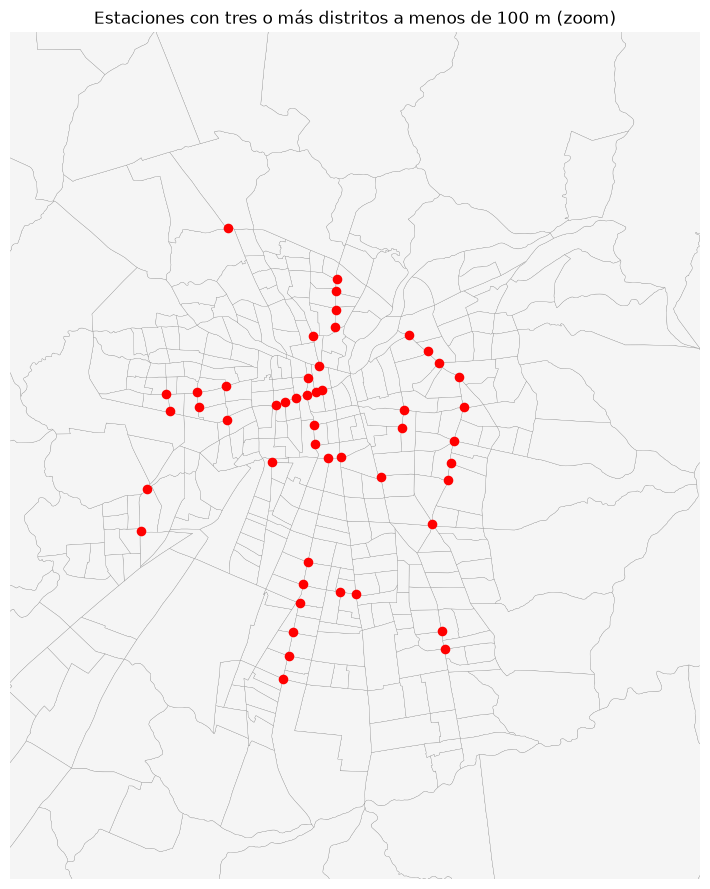

In [10]:
buffers = estaciones[['LINEA', 'NOMBRE', 'geometry']].copy()

buffers['geometry'] = buffers.buffer(100)

cercanias = gpd.sjoin(buffers, distritos[['CODIGO', 'geometry']], predicate='intersects')

conteo = cercanias.groupby(['LINEA', 'NOMBRE'])['CODIGO'].nunique()
estaciones_3 = conteo[conteo >= 3].rename('n_distritos_100m').reset_index()
display(estaciones_3)

mapa_estaciones_3 = estaciones.merge(estaciones_3[['LINEA', 'NOMBRE']], on=['LINEA', 'NOMBRE'])
ax = distritos.plot(color='whitesmoke', edgecolor='gray', figsize=(11, 11), linewidth=0.2)
mapa_estaciones_3.plot(ax=ax, color='red', markersize=35)

xmin, ymin, xmax, ymax = santiago_urbano.total_bounds
ax.set_xlim(xmin - 3000, xmax + 3000)
ax.set_ylim(ymin - 3000, ymax + 3000)
plt.title('Estaciones con tres o más distritos a menos de 100 m (zoom)')
plt.axis('off');

## Parte 2c - Ranking de comunas por estaciones

`sjoin` asigna cada punto de estación a la comuna que lo contiene. 

El ranking cuenta nombres de estación únicos por comuna y se muestra como tabla y mapa. 

La escala de color permite comparar comunas y los puntos rojos ubican las estaciones.

,Comuna,Estaciones
0,Santiago,20
1,Providencia,10
2,La Florida,9
3,Ñuñoa,8
4,Recoleta,7
5,Las Condes,7
6,Estación Central,6
7,Lo Prado,5
8,Puente Alto,5
9,Macul,5


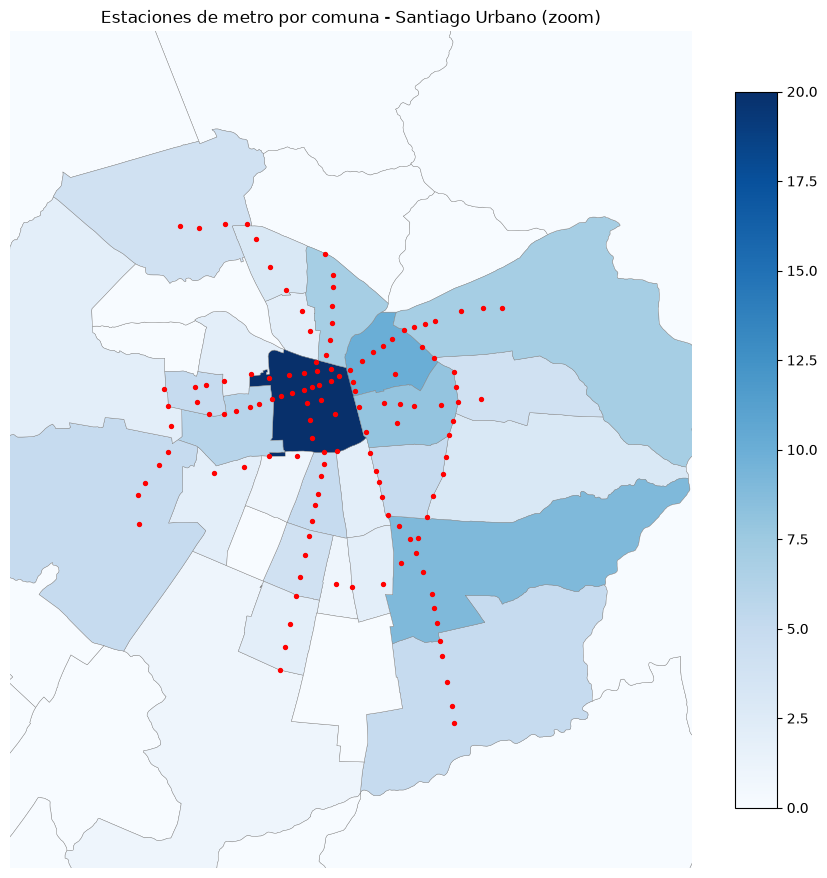

In [11]:
estaciones_comuna = gpd.sjoin(estaciones, comunas[['Comuna', 'geometry']], predicate='within')
ranking = estaciones_comuna.groupby('Comuna')['NOMBRE'].nunique().sort_values(ascending=False).rename('Estaciones').reset_index()
display(ranking)

mapa_comunas = comunas.merge(ranking, on='Comuna', how='left')

mapa_comunas['Estaciones'] = mapa_comunas['Estaciones'].fillna(0)

ax = mapa_comunas.plot(column='Estaciones', cmap='Blues', legend=True,
                        figsize=(11, 11), edgecolor='gray', linewidth=0.3)
estaciones.plot(ax=ax, color='red', markersize=8)
xmin, ymin, xmax, ymax = santiago_urbano.total_bounds
ax.set_xlim(xmin - 3000, xmax + 3000)
ax.set_ylim(ymin - 3000, ymax + 3000)
plt.title('Estaciones de metro por comuna - Santiago Urbano (zoom)')
plt.axis('off');